In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from da_models.lorenz96 import rhs as rhs_l96
from da_models.integrators import euler_maruyama

## One-Layer Lorenz-96

**Simulation**

In [2]:
ic_l96 = np.load("../data/lorenz96_ic.npy")
print(ic_l96.shape, ic_l96)

(40,) [ 4.66160401  5.73522194  2.4450368  -5.49930523  0.01879502  4.84637371
  7.99289536  2.82764591  5.98242882  7.27137156 -0.09438529  3.23375468
  0.72373064 -1.34685692  2.05953551  5.64375133  5.76883766  2.31713186
 -2.75765522 -0.72866924 -0.01051097  0.48523387  6.31731589  1.27231047
 -4.68460008  3.66716149  2.07042727  1.46206201  6.55530609  5.36743466
 -6.67585953  1.9143056   3.09720412  8.50726357  5.62452609 -1.18250315
 -1.15669241 -2.00673095  3.57873149  8.49639184]


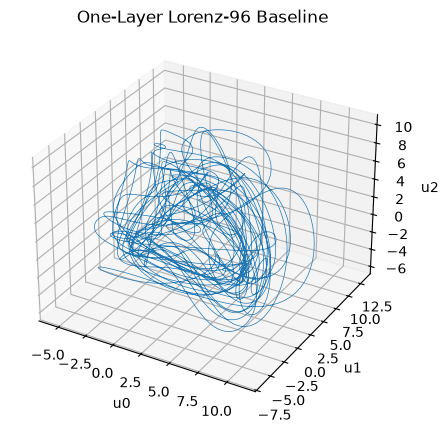

In [3]:
t_span = (0, 50)
t_eval = np.linspace(*t_span, 5000)

sol_l96 = solve_ivp(rhs_l96, t_span, ic_l96, t_eval=t_eval, args=(8.0, 1.0), rtol=1e-9, atol=1e-9)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(sol_l96.y[0], sol_l96.y[1], sol_l96.y[2], lw=0.5)
ax.set_xlabel('u0'); ax.set_ylabel('u1'); ax.set_zlabel('u2')
ax.set_title('One-Layer Lorenz-96 Baseline')
plt.show()

**Perturbation**

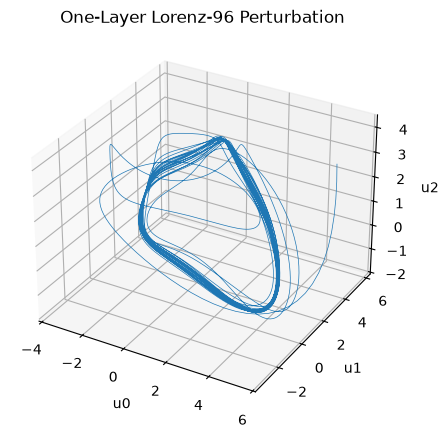

In [4]:
F_new = 4.0

sol_l96_tweak = solve_ivp(rhs_l96, t_span, ic_l96, t_eval=t_eval, args=(F_new, 1.0), rtol=1e-9, atol=1e-9)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(sol_l96_tweak.y[0], sol_l96_tweak.y[1], sol_l96_tweak.y[2], lw=0.5)
ax.set_xlabel('u0'); ax.set_ylabel('u1'); ax.set_zlabel('u2')
ax.set_title(f'One-Layer Lorenz-96 Perturbation')
plt.show()

**Additive Noise**

In [5]:
dt = 0.01
q = 1.0
seed = 0

t_noisy_l96, X_noisy_l96 = euler_maruyama(
    rhs_l96, ic_l96, t_span, dt=dt, q=q, seed=seed,
    rhs_kwargs={'F': 8.0, 'd': 1.0}
)

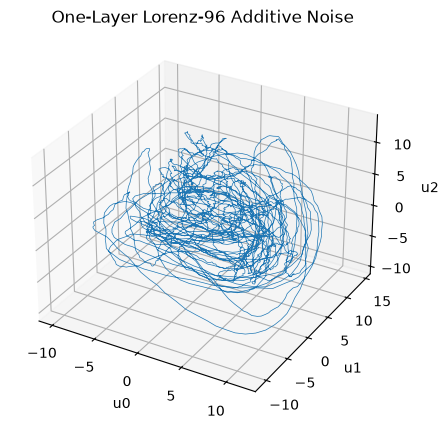

In [6]:
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.plot(X_noisy_l96[:, 0], X_noisy_l96[:, 1], X_noisy_l96[:, 2], lw=0.5)
ax.set_title(f'One-Layer Lorenz-96 Additive Noise')
ax.set_xlabel('u0'); ax.set_ylabel('u1'); ax.set_zlabel('u2')

plt.show()

**Observations**

Decreasing $F$ causes what seems like a limit cycle to appear, seemingly getting rid of the chaos. Adding noise does not affect the chaos.

## Two-Layer Lorenz-96

**Simulation**

In [7]:
from da_models.lorenz96 import rhs_two_layer, pack_two_layer, unpack_two_layer

In [8]:
K, J = 40, 5
ic_l96_2L = np.load("../data/lorenz96_two_layer_ic.npy")
print(ic_l96_2L.shape)

(240,)


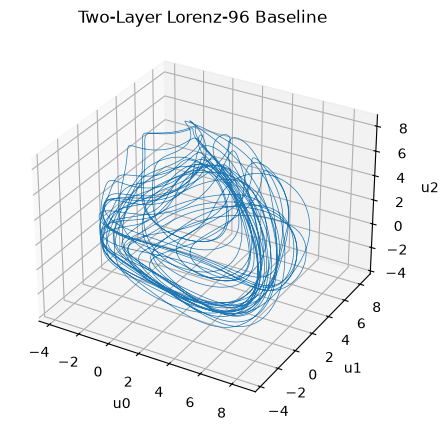

In [9]:
t_span = (0, 50)
t_eval = np.linspace(*t_span, 5000)

sol_2L = solve_ivp(
    rhs_two_layer, t_span, ic_l96_2L, t_eval=t_eval,
    args=(K, J, 8.0, 1.0, 0.05, (0.2, 0.5, 1.0, 2.0, 5.0)),
    rtol=1e-9, atol=1e-9,
)

u_traj_2L = sol_2L.y[:K]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(u_traj_2L[0], u_traj_2L[1], u_traj_2L[2], lw=0.5)
ax.set_xlabel('u0'); ax.set_ylabel('u1'); ax.set_zlabel('u2')
ax.set_title('Two-Layer Lorenz-96 Baseline')
plt.show()

**Perturbation**

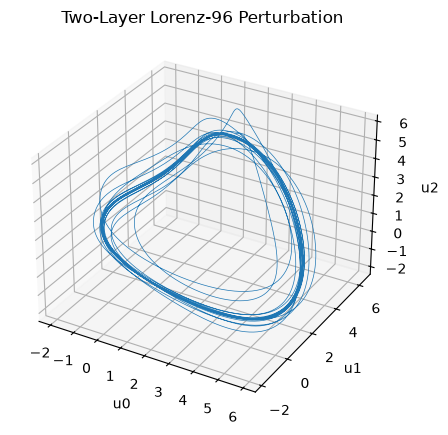

In [10]:
gamma_new = 0.1

sol_2L_tweak = solve_ivp(
    rhs_two_layer, t_span, ic_l96_2L, t_eval=t_eval,
    args=(K, J, 8.0, 1.0, gamma_new, (0.2, 0.5, 1.0, 2.0, 5.0)),
    rtol=1e-9, atol=1e-9,
)

u_traj_2L_tweak = sol_2L_tweak.y[:K]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(projection='3d')
ax.plot(u_traj_2L_tweak[0], u_traj_2L_tweak[1], u_traj_2L_tweak[2], lw=0.5)
ax.set_xlabel('u0'); ax.set_ylabel('u1'); ax.set_zlabel('u2')
ax.set_title(f'Two-Layer Lorenz-96 Perturbation')
plt.show()

**Additive Noise**

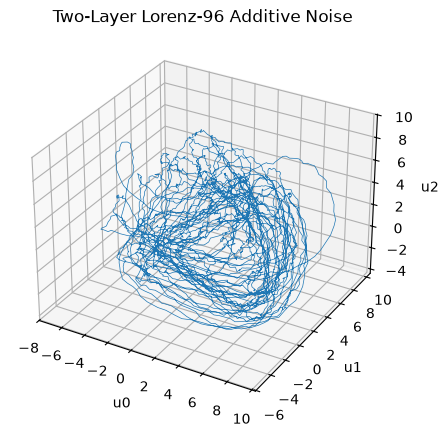

In [11]:
dt = 0.01
q = 1.0
seed = 0

t_noisy_2L, X_noisy_2L = euler_maruyama(
    rhs_two_layer, ic_l96_2L, t_span, dt=dt, q=q, seed=seed,
    rhs_kwargs={'K': K, 'J': J, 'F': 8.0, 'd': 1.0, 'gamma': 0.05,
                'd_j': (0.2, 0.5, 1.0, 2.0, 5.0)}
)

fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.plot(X_noisy_2L[:, 0], X_noisy_2L[:, 1], X_noisy_2L[:, 2], lw=0.5)
ax.set_title(f'Two-Layer Lorenz-96 Additive Noise')
ax.set_xlabel('u0'); ax.set_ylabel('u1'); ax.set_zlabel('u2')
plt.show()

**Observations**

Increasing $\gamma$ causes a limit cycle to appear, getting rid of the chaos. Noise does not get rid of the chaos.